QUESTION NUMBER 10, CHAPTER 12, PAGE 555 OF THE TEXTBOOK "AN INTRODUCTION TO STATISTICAL LEARNING WITH APPLICATIONS IN PYTHON".

In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

QUESTION A

Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We set the seed for reproducibility
np.random.seed(4)

In [2]:
# Parameters
n_classes = 3
n_obs_per_class = 20
n_features = 50

In [3]:
# Generate data for each class with distinct mean shifts
class_1 = np.random.normal(loc=0, scale=1, size=(n_obs_per_class, n_features))
class_2 = np.random.normal(loc=3, scale=1, size=(n_obs_per_class, n_features))  # shifted mean
class_3 = np.random.normal(loc=-3, scale=1, size=(n_obs_per_class, n_features)) # shifted mean

In [4]:
# Combine into one dataset
X = np.vstack((class_1, class_2, class_3))
y = np.array([1]*n_obs_per_class + [2]*n_obs_per_class + [3]*n_obs_per_class)

# Wrap into a DataFrame
df = pd.DataFrame(X)
df['true labels'] = y

Question B

Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

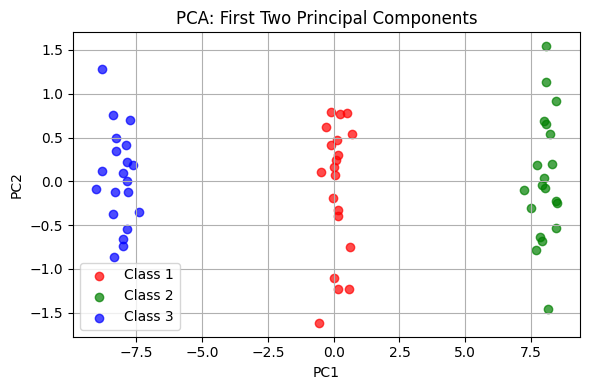

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Standardize the data (important for PCA)
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the first two principal components
plt.figure(figsize=(6, 4))
colors = ['red', 'green', 'blue']
labels = ['Class 1', 'Class 2', 'Class 3']

for i in range(3):
    plt.scatter(X_pca[y == i+1, 0], X_pca[y == i+1, 1], 
                color=colors[i], label=labels[i], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Principal Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

QUESTION C

Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels? Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [6]:
from sklearn.cluster import KMeans

# Clustering using 3 clusters using raw data
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Add clustering results to the DataFrame
df['Cluster'] = clusters+1

# Compare using crosstab
comparison = pd.crosstab(df['true labels'], df['Cluster'])
print(comparison)

Cluster       1   2   3
true labels            
1             0   0  20
2            20   0   0
3             0  20   0


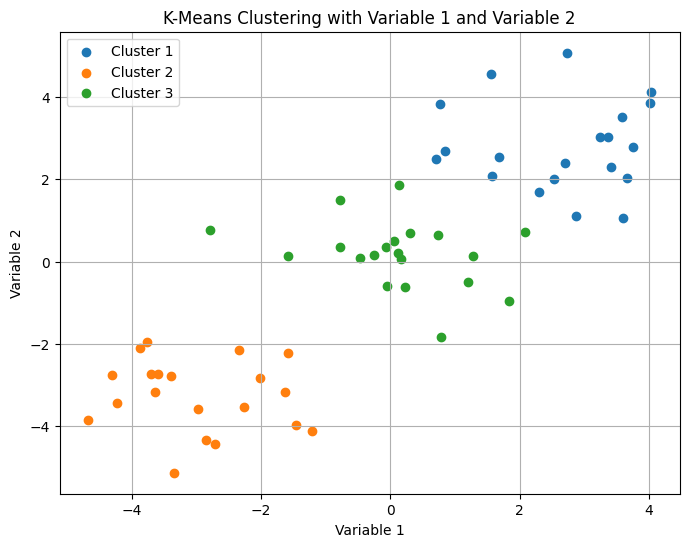

In [7]:
# Just to have a little glimpse of the clustering using the variable 1 and 2 from raw data 
plt.figure(figsize=(6, 4))
for cluster_id in np.unique(clusters):
    plt.scatter(X[clusters == cluster_id, 0],
                X[clusters == cluster_id, 1],
                label=f'Cluster {cluster_id+1}')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.legend()
plt.title('K-Means Clustering with Variable 1 and Variable 2')
plt.grid(True)
plt.show()

QUESTION D

Perform K-means clustering with K = 2. Describe your results.

In [8]:
# Clustering using 2 clusters
kmeans_2 = KMeans(n_clusters=2, random_state=42)
clusters_2 = kmeans_2.fit_predict(X)

# Add clustering results to the DataFrame
df['Cluster_2'] = clusters_2+1

# Compare using crosstab
comparison = pd.crosstab(df['true labels'], df['Cluster_2'])
print(comparison)

Cluster_2     1   2
true labels        
1            20   0
2            20   0
3             0  20


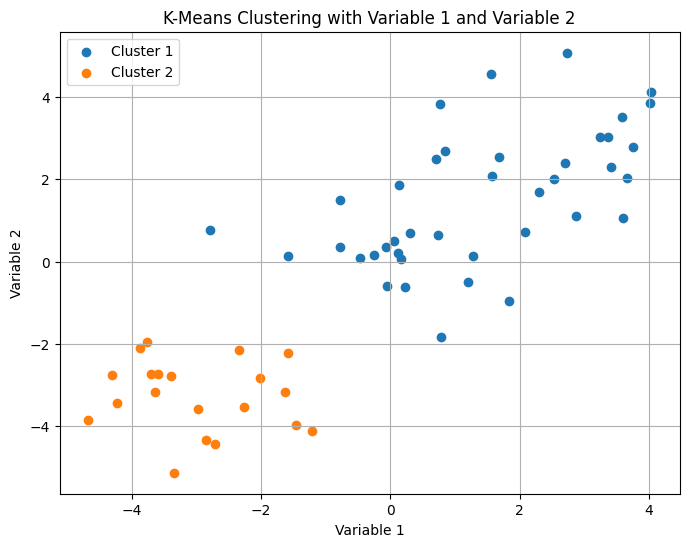

In [9]:
# Just to have a little glimpse of the clustering using the variable 1 and 2 from raw data 
plt.figure(figsize=(6, 4))
for cluster_id in np.unique(clusters_2):
    plt.scatter(X[clusters_2 == cluster_id, 0],
                X[clusters_2 == cluster_id, 1],
                label=f'Cluster {cluster_id+1}')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('K-Means Clustering with Variable 1 and Variable 2')
plt.legend()
plt.grid(True)
plt.show()

The result shows that when we cluster the data into 2 clusters only, 2 out of the 3 classes are combined into 1 cluster.

QUESTION E

Now perform K-means clustering with K = 4, and describe your results.

In [10]:
# Clustering using 4 clusters
kmeans_4 = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans_4.fit_predict(X)

# Add clustering results to the DataFrame
df['Cluster_4'] = clusters_4+1

# Compare using crosstab
comparison = pd.crosstab(df['true labels'], df['Cluster_4'])
print(comparison)

Cluster_4     1   2   3   4
true labels                
1             0   0  20   0
2            10   0   0  10
3             0  20   0   0


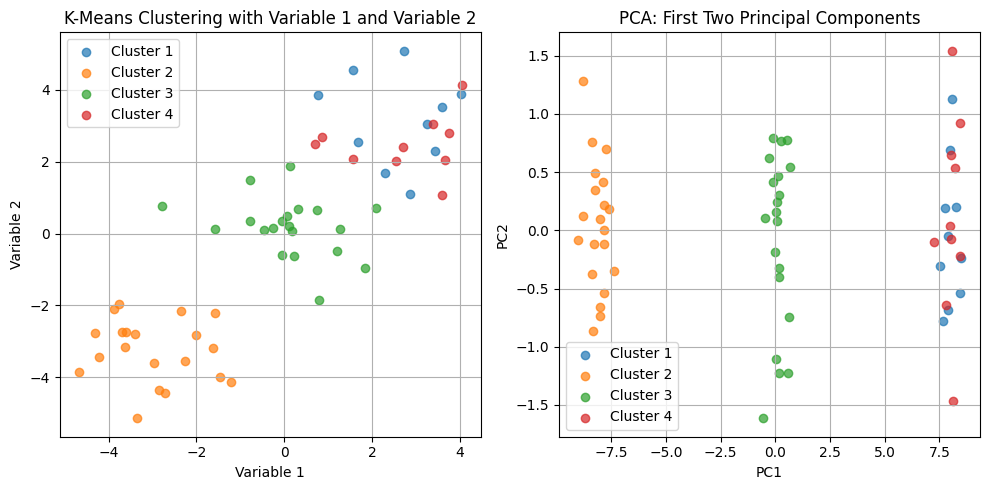

In [11]:
# Just to have a little glimpse of the clustering using the variable 1 and 2 from raw data 

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

for cluster_id in np.unique(clusters_4):
    axes[0].scatter(X[clusters_4 == cluster_id, 0],
                    X[clusters_4 == cluster_id, 1],
                    label=f'Cluster {cluster_id+1}', alpha = 0.7)
    axes[1].scatter(X_pca[clusters_4 == cluster_id, 0], 
                    X_pca[clusters_4 == cluster_id, 1], 
                    label=f'Cluster {cluster_id+1}', alpha = 0.7)
axes[0].set_xlabel('Variable 1')
axes[0].set_ylabel('Variable 2')
axes[0].set_title('K-Means Clustering with Variable 1 and Variable 2')
axes[0].legend()
axes[0].grid(True)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA: First Two Principal Components')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The result shows that when we cluster the data into 4 clusters, 1 of the classes is divided into 2 clusters. It seems like the class that is divided into 2 clusters is the one with the widest spread/range in their PCA visualization (tried it several times with different seeds).

QUESTION F

Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

In [12]:
# Clustering using 3 clusters with loading scores from PCA
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Add clustering results to the DataFrame
df['Cluster_pca'] = clusters_pca+1

# Compare using crosstab
comparison = pd.crosstab(df['true labels'], df['Cluster_pca'])
print(comparison)

Cluster_pca   1   2   3
true labels            
1             0   0  20
2            20   0   0
3             0  20   0


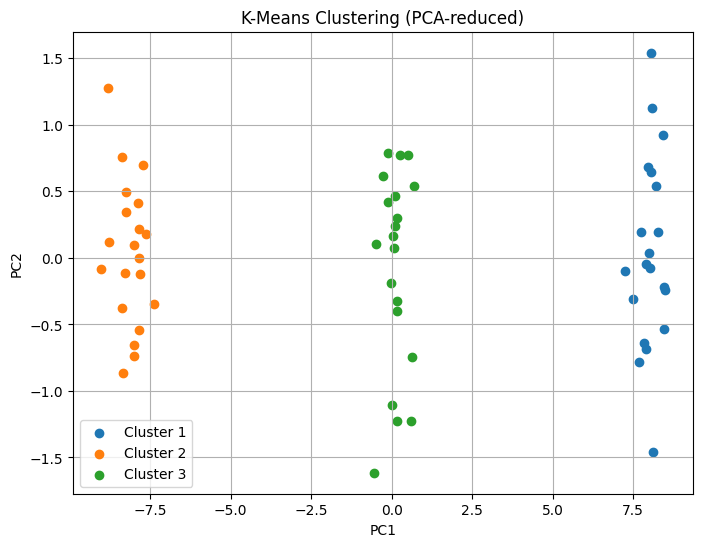

In [13]:
# Drawing the scatterplot for the clusters of PCA loading scores
plt.figure(figsize=(8, 6))
for cluster_id in np.unique(clusters_pca):
    plt.scatter(X_pca[clusters_pca == cluster_id, 0],
                X_pca[clusters_pca == cluster_id, 1],
                label=f'Cluster {cluster_id+1}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (PCA-reduced)')
plt.legend()
plt.grid(True)
plt.show()

The results mirror those of QUESTION B, as the data were initially generated with three distinct classes featuring shifted means—naturally forming clusters from the outset.

QUESTION G

Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

In [14]:
# Clustering using 3 clusters with scaled features from X array
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)

# Add clustering results to the DataFrame
df['Cluster_scaled'] = clusters_scaled+1

# Compare using crosstab
comparison = pd.crosstab(df['true labels'], df['Cluster_scaled'])
print(comparison)

Cluster_scaled   1   2   3
true labels               
1                0   0  20
2               20   0   0
3                0  20   0


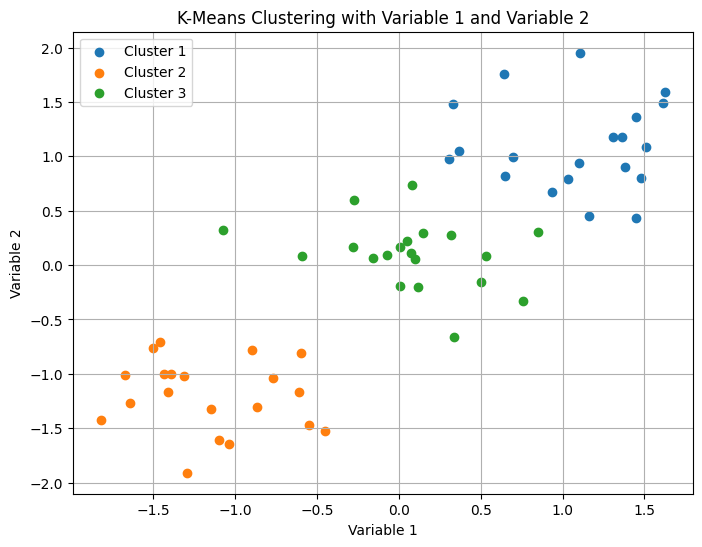

In [15]:
# Just to have a little glimpse of the clustering using the variable 1 and 2 from scaled raw data
plt.figure(figsize=(8, 6))
for cluster_id in np.unique(clusters_scaled):
    plt.scatter(X_scaled[clusters_scaled == cluster_id, 0],
                X_scaled[clusters_scaled == cluster_id, 1],
                label=f'Cluster {cluster_id+1}')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('K-Means Clustering with Variable 1 and Variable 2')
plt.legend()
plt.grid(True)
plt.show()

The result shows no difference in terms of the clustering result. Every data point is cleanly clustered in 3 clusters completely without any difference